# Clustering

## K-Means聚类演示

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

生成合成数据集：4个簇，2维平面
样本数量: 100
特征维度: 2
真实簇数: 4


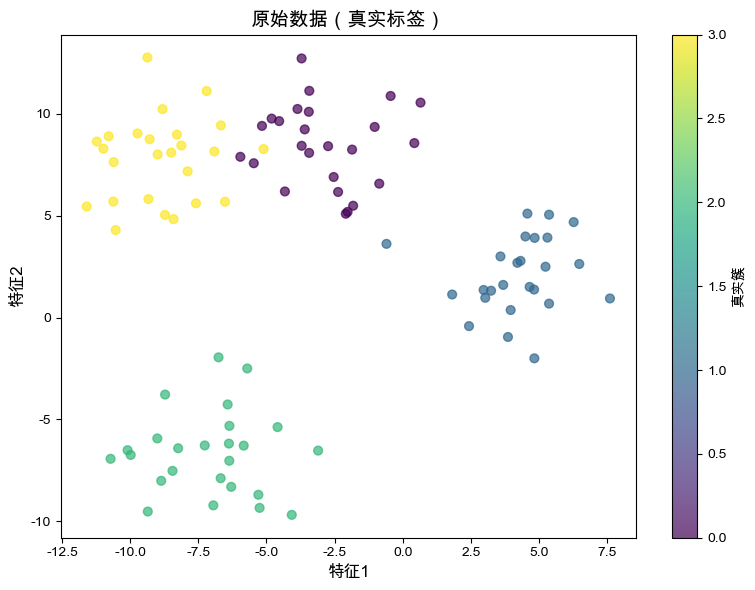

In [16]:
# ========== 1. 生成合成数据集（4个簇） ==========
print("=" * 60)
print("生成合成数据集：4个簇，2维平面")
print("=" * 60)

# 生成4个簇的数据点
X, y_true = make_blobs(n_samples=100, centers=4, 
                       cluster_std=2, random_state=42)

print(f"样本数量: {X.shape[0]}")
print(f"特征维度: {X.shape[1]}")
print(f"真实簇数: {len(np.unique(y_true))}")

# 可视化原始数据
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=40, alpha=0.7)
ax.set_xlabel('特征1', fontsize=12)
ax.set_ylabel('特征2', fontsize=12)
ax.set_title('原始数据（真实标签）', fontsize=14)
plt.colorbar(scatter, label='真实簇')
plt.tight_layout()
plt.show()

In [ ]:
# ========== 2. 手动实现K-Means（用于动画演示） ==========
class KMeansVisualizer:
    """带可视化功能的K-Means实现"""
    
    def __init__(self, n_clusters=4, max_iters=20, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.history = {'centroids': [], 'labels': []}
    
    def init_centroids(self, X):
        """随机初始化中心点（从数据点中选取）"""
        np.random.seed(self.random_state)
        indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[indices].copy()
        return self.centroids
    
    def assign_labels(self, X):
        """安全版距离计算，不爆内存"""
        from sklearn.metrics.pairwise import euclidean_distances
        distances = euclidean_distances(X, self.centroids)
        self.labels = np.argmin(distances, axis=1)
        return self.labels
    
    def update_centroids(self, X):
        """更新中心点为所属点的均值"""
        new_centroids = np.zeros_like(self.centroids)
        for j in range(self.n_clusters):
            points_in_cluster = X[self.labels == j]
            if len(points_in_cluster) > 0:
                new_centroids[j] = points_in_cluster.mean(axis=0)
            else:
                new_centroids[j] = self.centroids[j]  # 空簇保持原位置
        return new_centroids
    
    def fit(self, X):
        """训练K-Means，记录每一步的历史"""
        self.init_centroids(X)
        
        for epoch in range(self.max_iters):
            # 记录当前状态
            self.history['centroids'].append(self.centroids.copy())
            
            # 分配标签
            self.assign_labels(X)
            self.history['labels'].append(self.labels.copy())
            
            # 更新中心点
            new_centroids = self.update_centroids(X)
            
            # 检查收敛（中心点不再变化）
            if np.allclose(self.centroids, new_centroids):
                print(f"算法在第 {epoch + 1} 步收敛")
                break
            
            self.centroids = new_centroids
        
        # 记录最终状态
        self.history['centroids'].append(self.centroids.copy())
        self.history['labels'].append(self.labels.copy())
        
        return self

In [30]:
# # ========== 3. 训练K-Means并记录历史 ==========
# print("\n" + "=" * 60)
# print("训练K-Means，记录每一步迭代")
# print("=" * 60)

# kmeans_viz = KMeansVisualizer(n_clusters=4, max_iters=15, random_state=42)
# kmeans_viz.fit(X)

# print(f"总迭代步数: {len(kmeans_viz.history['centroids'])} (包含初始状态)")

# 使用sklearn的KMeans作为对比
# sklearn_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
# sklearn_kmeans.fit(X)
# print(f"sklearn K-Means 收敛于 {sklearn_kmeans.n_iter_} 步")

In [32]:
# ========== 3. 训练K-Means并记录历史 ==========
print("\n" + "=" * 60)
print("训练K-Means，记录每一步迭代")
print("=" * 60)
kmeans_viz = KMeansVisualizer(n_clusters=4, max_iters=10, random_state=44)
kmeans_viz.fit(X)


训练K-Means，记录每一步迭代
算法在第 7 步收敛


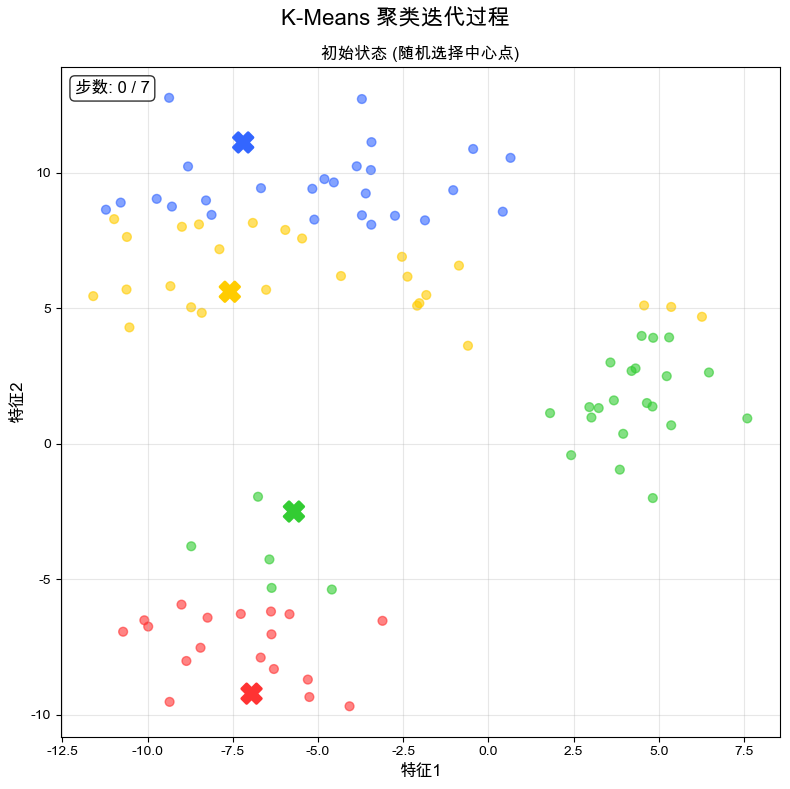

In [33]:
# ========== 4. 动画演示迭代过程 ==========
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

colors = ['#FF3333', '#3366FF', '#FFCC00', '#33CC33']  # 4种不同的颜色

fig, ax = plt.subplots(figsize=(8, 8))
fig.suptitle('K-Means 聚类迭代过程', fontsize=16, fontweight='bold')

# 获取总步数
n_steps = len(kmeans_viz.history['centroids'])

# 初始化散点图和中心点
scatter = ax.scatter(X[:, 0], X[:, 1], c='gray', s=40, alpha=0.6, zorder=1)
centroid_scatter = ax.scatter([], [], c='red', s=200, marker='X', 
                              edgecolors='black', linewidths=2, zorder=2)

# 设置坐标轴
ax.set_xlabel('特征1', fontsize=12)
ax.set_ylabel('特征2', fontsize=12)
ax.set_title('初始化状态 (步数: 0)', fontsize=12)
ax.grid(True, alpha=0.3)  # 增加网格更清晰

# 添加步数显示文本
step_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                    fontsize=12, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

def update(frame):
    """更新动画的每一帧"""
    # 获取当前步的标签和中心点
    labels = kmeans_viz.history['labels'][frame]
    centroids = kmeans_viz.history['centroids'][frame]
    
    # ✅ 修复1：用 set_facecolor 而不是 set_color（散点颜色必须用这个API）
    point_colors = [colors[label] for label in labels]
    scatter.set_facecolor(point_colors)
    
    # 更新中心点
    centroid_scatter.set_offsets(centroids)
    # 中心点颜色随簇变化
    centroid_scatter.set_color([colors[j] for j in range(len(centroids))])
    
    # 更新标题
    if frame == 0:
        ax.set_title(f'初始状态 (随机选择中心点)', fontsize=12)
    elif frame < n_steps - 1:
        ax.set_title(f'迭代第 {frame} 步 (共 {n_steps-1} 步)', fontsize=12)
    else:
        ax.set_title(f'收敛完成！最终聚类结果', fontsize=12)
    
    # 更新步数显示
    step_text.set_text(f'步数: {frame} / {n_steps-1}')
    
    return scatter, centroid_scatter, step_text

# ✅ 修复2：关闭 blit（中文+动态标题必须关闭，否则会闪烁/黑屏）
anim = FuncAnimation(fig, update, frames=n_steps, interval=1000, repeat=True, blit=False)

plt.tight_layout()

# ✅ 修复3：Jupyter 显示必须放在 plt.show() 之前！
from IPython.display import HTML
html_anim = HTML(anim.to_jshtml())

# 最后再显示
# plt.show()

In [34]:
# 输出动画（Jupyter 专用）
html_anim

In [35]:
# 保存为GIF（可选）
anim.save('kmeans_iter07.gif', writer='pillow', fps=1)

In [ ]:
# 2026年1-4月70城新房数据
data_2026_april_housing = [
    ["北京", 99.8, 97.7, 97.7],
    ["天津", 100.0, 94.9, 95.5],
    ["石家庄", 99.8, 95.3, 95.5],
    ["太原", 100.2, 97.8, 98.2],
    ["呼和浩特", 99.8, 96.1, 96.0],
    ["沈阳", 100.0, 100.1, 99.8],
    ["大连", 100.2, 99.2, 99.1],
    ["长春", 99.6, 97.7, 97.6],
    ["哈尔滨", 99.9, 97.6, 97.4],
    ["上海", 100.4, 103.7, 103.9],
    ["南京", 100.3, 96.6, 96.3],
    ["杭州", 100.4, 102.3, 102.5],
    ["宁波", 100.1, 98.0, 98.1],
    ["合肥", 100.0, 100.9, 101.2],
    ["福州", 99.7, 94.7, 95.7],
    ["厦门", 99.9, 96.6, 96.8],
    ["南昌", 99.5, 94.5, 94.8],
    ["济南", 99.8, 96.2, 96.6],
    ["青岛", 100.1, 97.0, 97.1],
    ["郑州", 99.9, 94.1, 94.3],
    ["武汉", 100.0, 96.1, 96.2],
    ["长沙", 99.8, 96.6, 97.2],
    ["广州", 100.1, 95.6, 95.1],
    ["深圳", 100.1, 94.7, 94.7],
    ["南宁", 99.8, 96.6, 97.4],
    ["海口", 100.0, 94.6, 94.6],
    ["重庆", 99.9, 95.2, 95.9],
    ["成都", 99.8, 95.0, 95.9],
    ["贵阳", 99.7, 95.8, 96.1],
    ["昆明", 99.6, 93.7, 93.7],
    ["西安", 99.7, 94.4, 94.4],
    ["兰州", 99.9, 95.8, 95.6],
    ["西宁", 99.4, 96.4, 96.6],
    ["银川", 100.1, 97.3, 96.7],
    ["乌鲁木齐", 100.2, 100.1, 100.3],
    ["唐山", 99.5, 93.8, 93.8],
    ["秦皇岛", 99.5, 94.6, 94.8],
    ["包头", 99.7, 92.7, 92.7],
    ["丹东", 99.9, 98.0, 97.7],
    ["锦州", 99.8, 97.3, 97.0],
    ["吉林", 100.4, 98.6, 97.7],
    ["牡丹江", 99.9, 98.7, 98.4],
    ["无锡", 99.6, 95.2, 95.2],
    ["徐州", 100.0, 95.1, 94.8],
    ["扬州", 99.8, 94.5, 94.7],
    ["温州", 99.9, 96.0, 95.7],
    ["金华", 99.8, 95.6, 95.8],
    ["蚌埠", 99.7, 96.5, 96.3],
    ["安庆", 99.6, 96.6, 96.5],
    ["泉州", 99.8, 96.2, 96.8],
    ["九江", 99.5, 95.9, 96.1],
    ["赣州", 99.8, 95.5, 95.6],
    ["烟台", 100.2, 96.4, 96.0],
    ["济宁", 99.9, 95.2, 95.1],
    ["洛阳", 99.4, 94.7, 95.4],
    ["平顶山", 99.7, 97.5, 97.9],
    ["宜昌", 99.6, 99.7, 100.0],
    ["襄阳", 100.0, 94.7, 95.2],
    ["岳阳", 99.6, 95.4, 95.4],
    ["常德", 99.7, 95.0, 95.3],
    ["韶关", 99.2, 97.6, 98.2],
    ["湛江", 99.8, 95.4, 95.8],
    ["惠州", 99.2, 94.8, 95.4],
    ["桂林", 99.5, 94.0, 94.7],
    ["北海", 99.4, 93.8, 93.9],
    ["三亚", 99.6, 98.7, 99.0],
    ["泸州", 99.3, 92.8, 93.3],
    ["南充", 99.4, 96.2, 96.6],
    ["遵义", 99.5, 96.2, 96.8],
    ["大理", 100.2, 96.5, 96.0]
]

# 说明：
# 每个子列表的结构为：[城市, 环比(上月=100), 同比(上年同月=100), 1-4月平均(上年同期=100)]
# 对应表头：城市 | 环比(上月=100) | 同比(上年同月=100) | 1-4月平均(上年同期=100)